# Домашнее задание: Анализ банковского маркетинга

## О датасете

Датасет Bank Marketing содержит результаты телефонных маркетинговых кампаний португальского банка. Задача состоит в предсказании, подпишется ли клиент на срочный депозит.

Датасет включает:
- Информацию о клиентах (возраст, работа, образование, семейное положение)
- Данные о последнем контакте (месяц, день недели, длительность звонка)
- Информацию о предыдущих кампаниях
- Социально-экономические показатели (уровень занятости, индекс потребительских цен, индекс потребительской уверенности, ставка Euribor)

Целевая переменная: `y` - подписался ли клиент на срочный депозит (yes/no)

Датасет доступен по ссылке: https://archive.ics.uci.edu/ml/datasets/Bank+Marketing

## Задание

Выполните полный цикл анализа данных по методологии CRISP-DM. В рамках каждого этапа решите предложенные задачи.

## 1. Business Understanding (Понимание бизнес-задачи)

**Задача 1.1:** Сформулируйте бизнес-задачу простыми словами. Какую проблему решает банк с помощью этого анализа? Почему важно предсказывать отклик клиентов на маркетинговую кампанию?

**Задача 1.2:** Определите метрику успеха проекта с точки зрения бизнеса. Какой процент правильно предсказанных откликов будет хорошим результатом для банка?

In [ ]:
# Ваш код здесь (если нужны расчеты)

## 2. Data Understanding (Понимание данных)

**Задача 2.1:** Загрузите данные из файла `bank-additional-full.csv` и выведите первые 5 строк датасета. Сколько всего записей в датасете?
41888 записей.

**Задача 2.2:** Выведите информацию о типах данных и наличии пропусков в каждом столбце. Есть ли пропущенные значения?
Пропущенных значений нет. Есть числовые и категориальные признаки.

**Задача 2.3:** Постройте распределение целевой переменной `y`. Сбалансирован ли датасет? Какой класс преобладает?
Датасет несбалансирован, преобладает класс no.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bank-additional-full.csv", sep=';')

df.head()
df.shape

df['y'].value_counts()


,count
y,
no,36548
yes,4640


**Задача 2.4:** Проанализируйте численные признаки. Выведите описательную статистику (mean, std, min, max) для возраста, длительности звонка, количества контактов в текущей кампании.

**Задача 2.5:** Постройте корреляционную матрицу для всех численных признаков. Какие признаки сильнее всего коррелируют с целевой переменной?

Сильнее всего кореллируют с целевой переменной у duration и previous.

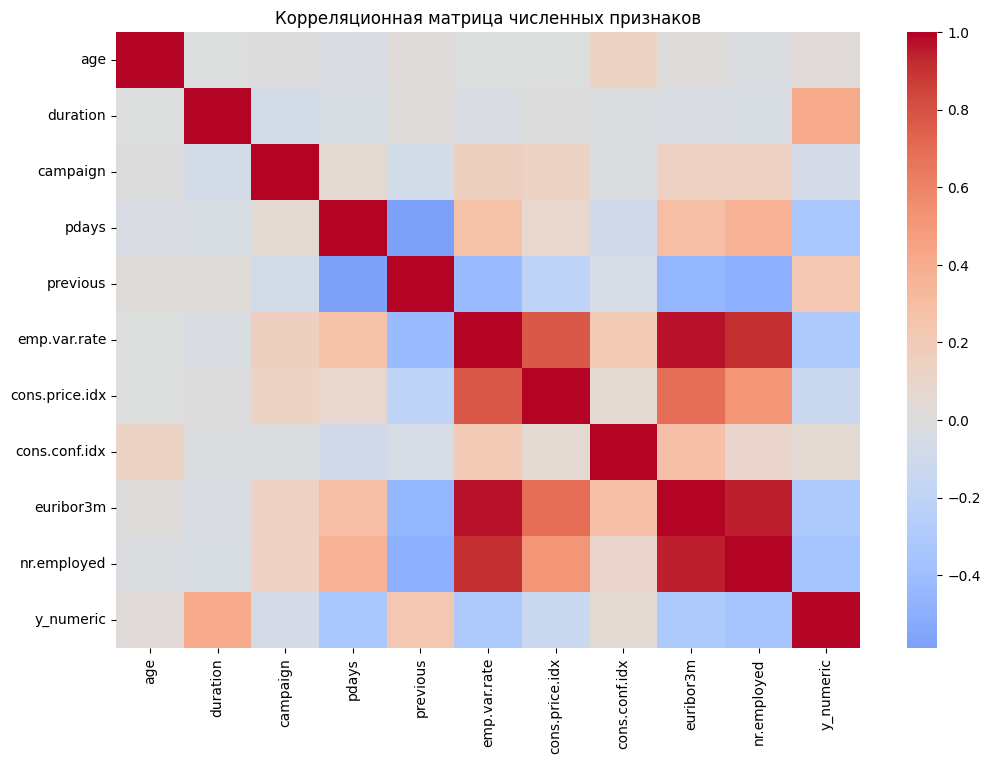

,y_numeric
y_numeric,1.000000
duration,0.405274
previous,0.230181
cons.conf.idx,0.054878
age,0.030399
campaign,-0.066357
cons.price.idx,-0.136211
emp.var.rate,-0.298334
euribor3m,-0.307771
pdays,-0.324914


In [4]:
 df[['age', 'duration', 'campaign']].describe()

df['y_numeric'] = df['y'].map({'no': 0, 'yes': 1})
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()
corr_matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица численных признаков')
plt.show()

corr_with_target = corr_matrix['y_numeric'].sort_values(ascending=False)
corr_with_target



**Задача 2.6:** Проанализируйте категориальные признаки. Постройте графики распределения для признаков `job`, `education`, `marital`. Какие категории встречаются чаще всего?
По признаку job чаще всего встречаются admin, по признаку education - university.degree и по признаку marital married.

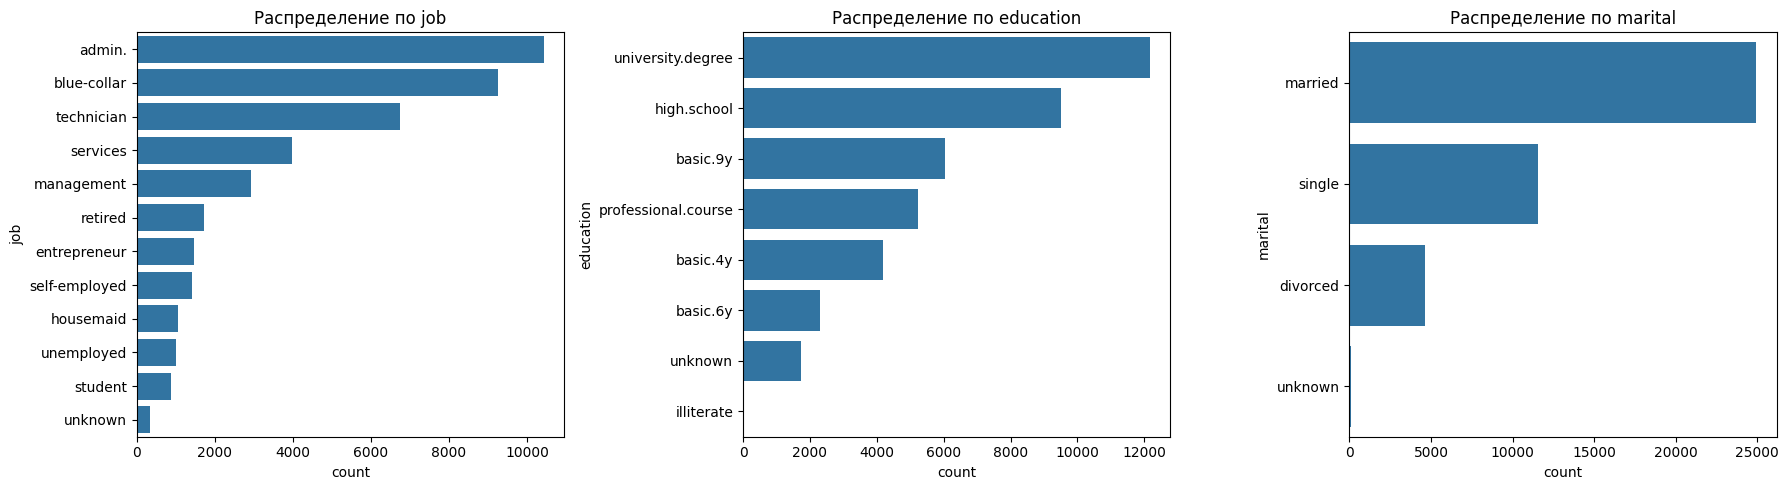

In [5]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title('Распределение по job')

plt.subplot(1, 3, 2)
sns.countplot(y='education', data=df, order=df['education'].value_counts().index)
plt.title('Распределение по education')

plt.subplot(1, 3, 3)
sns.countplot(y='marital', data=df, order=df['marital'].value_counts().index)
plt.title('Распределение по marital')

plt.tight_layout()
plt.show()


## 3. Data Preparation (Подготовка данных)

**Задача 3.1:** Обработайте категориальные признаки с метками "unknown". Решите, заменить их на наиболее частое значение или удалить соответствующие строки.

**Задача 3.2:** Преобразуйте целевую переменную `y` в бинарный формат (0 и 1).

In [7]:
df_prep = df.copy()

categorical_cols = df_prep.select_dtypes(include='object').columns

for col in categorical_cols:
    if 'unknown' in df_prep[col].values:
        mode_value = df_prep.loc[df_prep[col] != 'unknown', col].mode()[0]
        df_prep[col] = df_prep[col].replace('unknown', mode_value)


**Задача 3.3:** Примените One-Hot Encoding к категориальным признакам. Сколько признаков получилось после кодирования?
63 признака

**Задача 3.4:** Проверьте наличие выбросов в признаке `duration` с помощью метода IQR. Удалите или обработайте выбросы.

In [9]:
X = df_prep.drop('y', axis=1)
y = df_prep['y']

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.shape

Q1 = X_encoded['duration'].quantile(0.25)
Q3 = X_encoded['duration'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound
mask = (X_encoded['duration'] >= lower_bound) & (X_encoded['duration'] <= upper_bound)

X_encoded_clean = X_encoded[mask]
y_clean = y[mask]
X_encoded_clean.shape

X_encoded['duration'] = X_encoded['duration'].clip(lower_bound, upper_bound)

**Задача 3.5:** Нормализуйте численные признаки с помощью StandardScaler. Почему важна нормализация для некоторых моделей машинного обучения?
Для ускорения обучения и для моделей, чувствительных к масштабу признаков.

In [10]:
from sklearn.preprocessing import StandardScaler

X_scaled = X_encoded_clean.copy()
numeric_cols = X_scaled.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])
X_scaled[numeric_cols].describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_numeric
count,3.822500e+04,3.822500e+04,3.822500e+04,3.822500e+04,3.822500e+04,3.822500e+04,3.822500e+04,3.822500e+04,3.822500e+04,3.822500e+04,38225.000000
mean,-1.368108e-16,8.327617e-17,8.327617e-17,2.617251e-16,2.379319e-17,1.903455e-16,7.827960e-15,-2.855183e-16,-9.517276e-17,1.313384e-14,0.000000
std,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013
min,-2.210937e+00,-1.441367e+00,-5.606395e-01,-5.213073e+00,-3.502161e-01,-2.215223e+00,-2.368752e+00,-2.227774e+00,-1.723926e+00,-2.823667e+00,-0.297809
25%,-7.721195e-01,-7.534985e-01,-5.606395e-01,1.930196e-01,-3.502161e-01,-1.197258e+00,-8.611926e-01,-4.791135e-01,-1.314393e+00,-9.438120e-01,-0.297809
50%,-1.965926e-01,-2.570986e-01,-2.047703e-01,1.930196e-01,-3.502161e-01,6.478022e-01,-2.247060e-01,-2.848179e-01,7.119256e-01,3.311597e-01,-0.297809
75%,6.666978e-01,5.229586e-01,1.510990e-01,1.930196e-01,-3.502161e-01,8.386705e-01,7.239868e-01,8.809561e-01,7.719134e-01,8.458653e-01,-0.297809
max,5.558677e+00,3.125513e+00,1.901217e+01,1.930196e-01,1.380523e+01,8.386705e-01,2.057331e+00,2.931855e+00,8.203651e-01,8.458653e-01,3.357858


**Задача 3.6:** Разделите данные на обучающую и тестовую выборки в пропорции 80/20. Используйте stratify для сохранения пропорций классов.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

X_train.shape, X_test.shape

((30580, 48), (7645, 48))

## 4. Modeling - Классификация (Моделирование)

**Задача 4.1:** Обучите модель логистической регрессии для предсказания отклика клиентов. Используйте подготовленные данные.

**Задача 4.2:** Сделайте предсказания на тестовой выборке и выведите classification report (precision, recall, f1-score для каждого класса).

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
print(classification_report(y_test, y_pred))

confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

          no       1.00      1.00      1.00      7022
         yes       1.00      1.00      1.00       623

    accuracy                           1.00      7645
   macro avg       1.00      1.00      1.00      7645
weighted avg       1.00      1.00      1.00      7645



array([[7022,    0],
       [   0,  623]])

**Задача 4.3:** Постройте confusion matrix для модели. Сколько False Positives и False Negatives получилось? Что хуже для банка - не позвонить потенциальному клиенту или потратить время на неперспективного клиента?

**Задача 4.4:** Постройте ROC-кривую и вычислите площадь под кривой (ROC-AUC). Насколько хорошо модель различает классы?

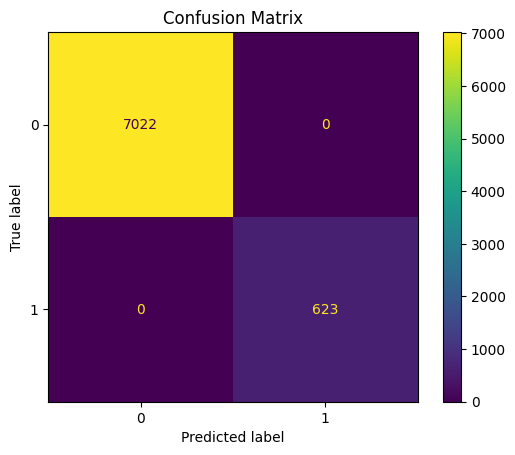

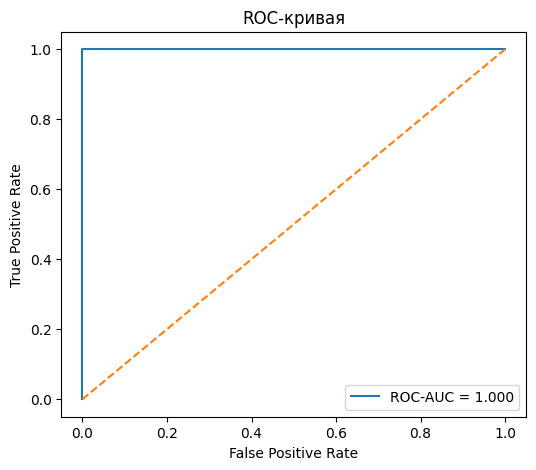

np.float64(1.0)

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

TN, FP, FN, TP = cm.ravel()
TN, FP, FN, TP

y_proba = log_reg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label='yes')
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

roc_auc

**Задача 4.5:** Попробуйте обучить дополнительную модель - Random Forest или Gradient Boosting. Сравните результаты с логистической регрессией.

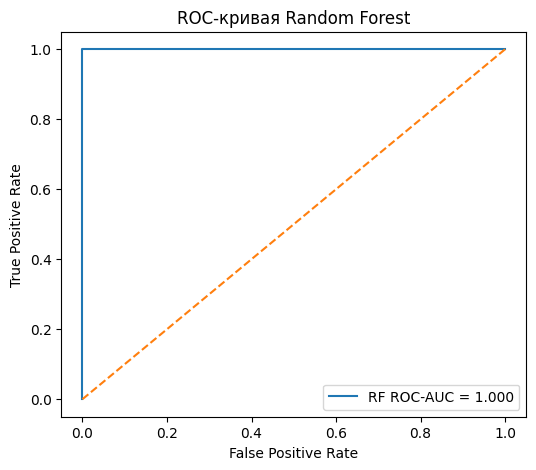

LogReg Accuracy: 1.0
LogReg ROC-AUC: 1.0
Разница ROC-AUC: 0.0


((30580, 48), (7645, 48))

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf, pos_label='yes')

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f'RF ROC-AUC = {roc_auc_rf:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая Random Forest')
plt.legend()
plt.show()

acc_lr = accuracy_score(y_test, y_pred)
roc_auc_lr = roc_auc_score(y_test, y_proba)

print("LogReg Accuracy:", acc_lr)
print("LogReg ROC-AUC:", roc_auc_lr)

print("Разница ROC-AUC:", roc_auc_rf - roc_auc_lr)

X_train.shape, X_test.shape




## 5. Modeling - Кластеризация (Моделирование)

**Задача 5.1:** Подготовьте данные для кластеризации. Выберите только численные признаки и нормализуйте их.

**Задача 5.2:** Используйте метод локтя (elbow method) для определения оптимального количества кластеров. Постройте график зависимости inertia от количества кластеров.

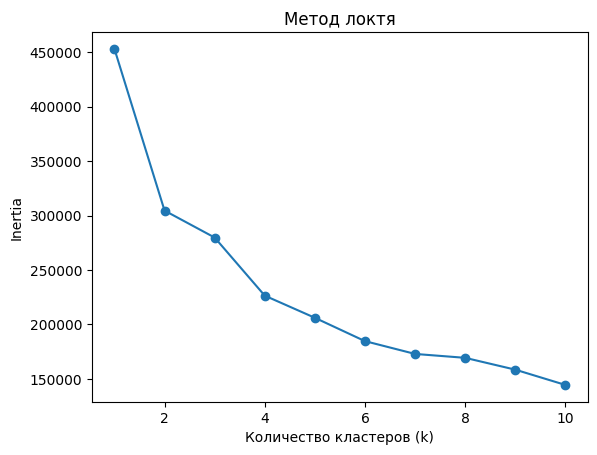

In [27]:
from sklearn.cluster import KMeans

X_num = df.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.show()


**Задача 5.3:** Вычислите коэффициент силуэта (silhouette score) для разного количества кластеров. Какое количество кластеров дает наилучший результат?

In [28]:
from sklearn.metrics import silhouette_score

scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

for k, score in zip(K, scores):
    print(f"k={k} -> silhouette score = {score:.4f}")

# лучший k
best_k = K[scores.index(max(scores))]
print(f"\nЛучшее количество кластеров: k = {best_k} (silhouette score = {max(scores):.4f})")


k=2 -> silhouette score = 0.4136
k=3 -> silhouette score = 0.4004
k=4 -> silhouette score = 0.4244
k=5 -> silhouette score = 0.4194
k=6 -> silhouette score = 0.4129
k=7 -> silhouette score = 0.2477
k=8 -> silhouette score = 0.3783
k=9 -> silhouette score = 0.2228
k=10 -> silhouette score = 0.2361

Лучшее количество кластеров: k = 4 (silhouette score = 0.4244)


**Задача 5.4:** Обучите модель KMeans с оптимальным количеством кластеров. Добавьте метки кластеров к исходным данным.

In [29]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


**Задача 5.5:** Примените PCA для снижения размерности до 2 компонент и визуализируйте кластеры на графике. Хорошо ли разделяются кластеры?

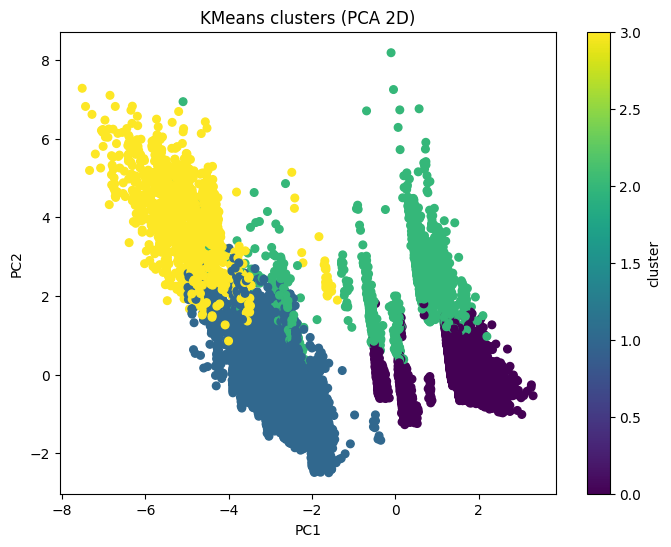

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', s=30)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans clusters (PCA 2D)')
plt.colorbar(label='cluster')
plt.show()


**Задача 5.6:** Проанализируйте характеристики каждого кластера. Вычислите средние значения признаков для каждого кластера. Как можно интерпретировать полученные сегменты клиентов?

In [33]:
cluster_summary = df.groupby('cluster')[X_num.columns].mean()
print(cluster_summary)


               age    duration  campaign       pdays  previous  emp.var.rate  \
cluster                                                                        
0        40.250964  206.325096  2.814148  999.000000  0.025559      1.119857   
1        39.407276  234.087594  2.125959  999.000000  0.321838     -2.030718   
2        39.298295  985.117898  2.503314  998.528409  0.059659      0.516241   
3        41.846454  319.075472  1.827586   20.875732  1.692908     -2.090046   

         cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y_numeric  
cluster                                                                    
0             93.845790     -39.424507   4.819063  5213.305547   0.000810  
1             92.982281     -43.155539   1.201991  5078.068006   0.168549  
2             93.680412     -40.753883   4.116565  5188.062453   0.798295  
3             93.350791     -38.331880   0.983187  5028.647040   0.636304  


## 6. Evaluation (Оценка)

**Задача 6.1:** Сравните результаты классификации и кластеризации. Есть ли связь между кластерами клиентов и их откликом на маркетинговую кампанию?

Да, связь есть. Доля отклика существенно различается по кластерам.
Их можно использовать для таргетинга потому что они различаются по отклику.

**Задача 6.2:** Проанализируйте важность признаков для лучшей модели классификации. Какие признаки наиболее важны для предсказания отклика?
duration, previous и campaign, эти признаки наиболее сильно связаны с откликом.


In [37]:
cluster_response = df.groupby('cluster')['y_numeric'].mean().sort_values(ascending=False)

print(cluster_response)



cluster
2    0.798295
3    0.636304
1    0.168549
0    0.000810
Name: y_numeric, dtype: float64


**Задача 6.3:** Сформулируйте выводы и рекомендации для банка на основе полученных результатов. На каких клиентов стоит сфокусировать маркетинговые усилия?


Ваши выводы здесь

Фокусировать маркетинг надо на кластерах 2 и 3, где высокий отклик. Не стоит тратить ресурсы на кластер 0.